In [ ]:
CSV_PATH = "Data Morocco - Laayoune.csv"
DATETIME_COL = "DateTime"
TARGET_COL = 'zone1'

## 10 min

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from lstm import load_and_prepare

df_10min = load_and_prepare(CSV_PATH, dt_col=DATETIME_COL, resample_rule='10min')

df_10min.describe()

ModuleNotFoundError: No module named 'experiments'

In [56]:
def interquartile_range(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    Q1 = df[target_col].quantile(0.25)
    Q3 = df[target_col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")

    return df[(df[target_col] >= lower_bound) & (df[target_col] <= upper_bound)]


df_no_outliers = interquartile_range(df=df_10min, target_col=TARGET_COL)

print("\nDataFrame after removing outliers:")
print(df_no_outliers)

Q1: 50.24
Q3: 78.02
IQR: 27.779999999999994
Lower Bound: 8.570000000000014
Upper Bound: 119.68999999999998

DataFrame after removing outliers:
                     zone1   zone2   zone3   zone4   zone5
DateTime                                                  
2022-09-14 17:10:00  73.54  120.92  160.98  122.24  102.92
2022-09-14 17:20:00  74.40  122.18  159.40  119.73  101.75
2022-09-14 17:30:00  77.89  124.70  159.97  118.51  102.07
2022-09-14 17:40:00  78.32  126.73  161.97  118.57  102.91
2022-09-14 17:50:00  81.33  125.74  163.19  120.69  102.55
...                    ...     ...     ...     ...     ...
2024-05-23 23:20:00  88.49  141.56  210.58  140.95  156.49
2024-05-23 23:30:00  86.87  143.22  211.09  140.56  159.15
2024-05-23 23:40:00  88.48  144.83  208.05  140.00  160.01
2024-05-23 23:50:00  87.50  144.07  207.86  140.18  158.46
2024-05-24 00:00:00  87.81  141.74  212.52  139.70  158.79

[88419 rows x 5 columns]


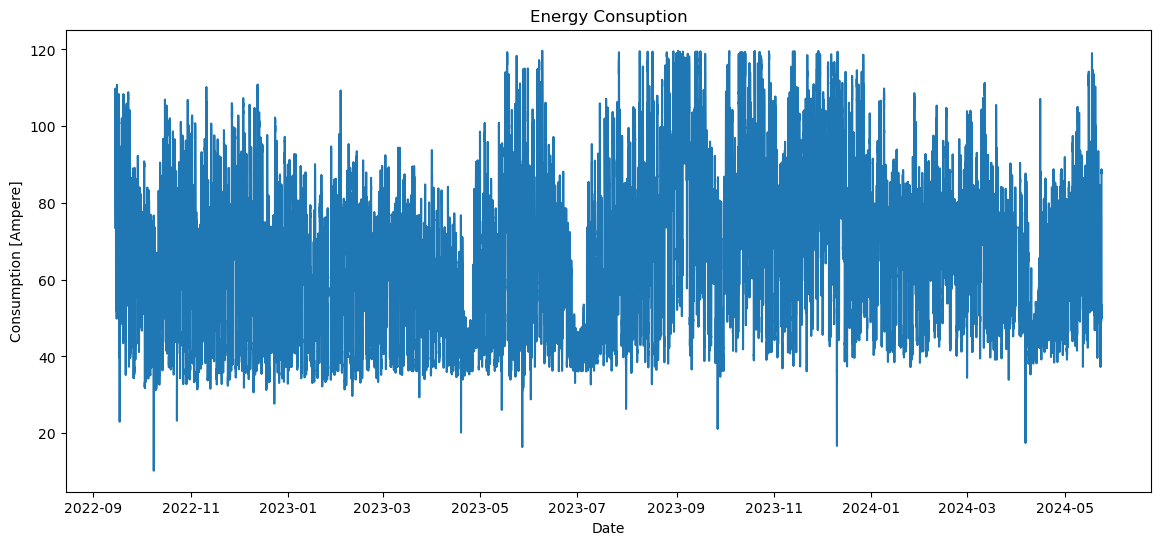

In [57]:
from typing import Optional

def time_plot(
    df: pd.DataFrame,
    target_col: str,
    title: Optional[str] = "Time Plot",
    ylabel: str = "Consumption [Ampere]"
) -> None:
    
    """
    Plots a time series for the specified target column.
    """

    # validation
    if target_col not in df.columns:
        raise ValueError(f"Column '{target_col}' not found in DataFrame.")
    
    # plot
    plt.figure(figsize=(14, 6))

    plt.plot(df.index, df[target_col])
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel("Date")
    plt.show()

time_plot(df=df_no_outliers, target_col=TARGET_COL, title='Energy Consuption')

In [58]:
import numpy as np

def extra_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # temporal index data
    year = df.index.year
    month = df.index.month
    hour = df.index.hour
    dayofweek = df.index.dayofweek          # 0=monday, 6=sunday
    dayofyear = df.index.dayofyear
    weekofyear = df.index.isocalendar().week.astype(int)

    # year and month
    df['year'] = [x for x in year]
    df['month'] = [x for x in month]
    
    # week
    df['day_week'] = [x for x in dayofweek]
    df['week_year'] = [x for x in weekofyear]

    # day
    df['day_week'] = [x for x in dayofweek]
    df['day_year'] = [x for x in dayofyear]
    df['hour'] = [x for x in hour]
    
    # cycles
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24)

    df['dow_sin'] = np.sin(2 * np.pi * dayofweek / 7)
    df['dow_cos'] = np.cos(2 * np.pi * dayofweek / 7)

    df['doy_sin'] = np.sin(2 * np.pi * dayofyear / 365)
    df['doy_cos'] = np.cos(2 * np.pi * dayofyear / 365)
    
    df['woy_sin'] = np.sin(2 * np.pi * weekofyear / 52)
    df['woy_cos'] = np.cos(2 * np.pi * weekofyear / 52)

    # weekend indicatior
    df['is_weekend'] = (dayofweek >= 5).astype(int)

    # time of day
    def get_time_of_day(h):
        if 0 <= h < 6:
            return "Night"
        elif 6 <= h < 12:
            return "Morning"
        elif 12 <= h < 18:
            return "Afternoon"
        else:
            return "Evening"

    df['time_of_day'] = [get_time_of_day(h) for h in hour]

    # One-hot encoding
    tod_dummies = pd.get_dummies(df['time_of_day'], prefix='tod')
    df = pd.concat([df.drop(columns='time_of_day'), tod_dummies], axis=1)

    return df

df_features = extra_features(df=df_no_outliers)

df_features


,zone1,zone2,zone3,zone4,zone5,year,month,day_week,week_year,day_year,...,dow_cos,doy_sin,doy_cos,woy_sin,woy_cos,is_weekend,tod_Afternoon,tod_Evening,tod_Morning,tod_Night
DateTime,,,,,,,,,,,,,,,,,,,,,
2022-09-14 17:10:00,73.54,120.92,160.98,122.24,102.92,2022,9,2,37,257,...,-0.222521,-0.958718,-0.284359,-0.970942,-0.239316,0,True,False,False,False
2022-09-14 17:20:00,74.40,122.18,159.40,119.73,101.75,2022,9,2,37,257,...,-0.222521,-0.958718,-0.284359,-0.970942,-0.239316,0,True,False,False,False
2022-09-14 17:30:00,77.89,124.70,159.97,118.51,102.07,2022,9,2,37,257,...,-0.222521,-0.958718,-0.284359,-0.970942,-0.239316,0,True,False,False,False
2022-09-14 17:40:00,78.32,126.73,161.97,118.57,102.91,2022,9,2,37,257,...,-0.222521,-0.958718,-0.284359,-0.970942,-0.239316,0,True,False,False,False
2022-09-14 17:50:00,81.33,125.74,163.19,120.69,102.55,2022,9,2,37,257,...,-0.222521,-0.958718,-0.284359,-0.970942,-0.239316,0,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-23 23:20:00,88.49,141.56,210.58,140.95,156.49,2024,5,3,21,144,...,-0.900969,0.615285,-0.788305,0.568065,-0.822984,0,False,True,False,False
2024-05-23 23:30:00,86.87,143.22,211.09,140.56,159.15,2024,5,3,21,144,...,-0.900969,0.615285,-0.788305,0.568065,-0.822984,0,False,True,False,False
2024-05-23 23:40:00,88.48,144.83,208.05,140.00,160.01,2024,5,3,21,144,...,-0.900969,0.615285,-0.788305,0.568065,-0.822984,0,False,True,False,False


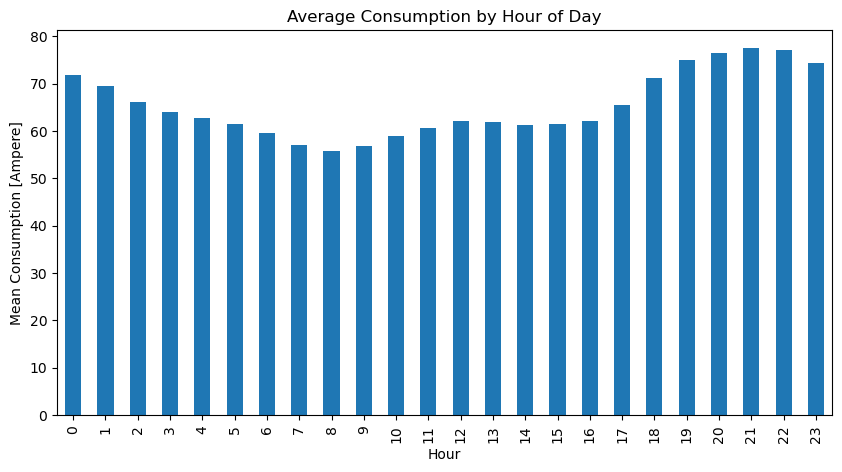

In [59]:
def hour_plot(
    df: pd.DataFrame,
    hour_col: str,
    target_col: str,
    title: Optional[str] = "Average Consumption by Hour of Day",
    ylabel: str = "Mean Consumption [Ampere]"
) -> None:
    """
    Plots the average target value by hour of day.
    """

    if target_col not in df.columns:
        raise ValueError(f"Column '{target_col}' not found in DataFrame.")
    if hour_col not in df.columns:
        raise ValueError(f"Column '{hour_col}' not found in DataFrame.")

    # hourly averages
    df = df.copy()
    df[hour_col] = df.index.hour
    hourly = df.groupby(hour_col)[target_col].mean()

    plt.figure(figsize=(10,5))
    hourly.plot(kind='bar')
    plt.title(title)
    plt.xlabel('Hour')
    plt.ylabel(ylabel)
    plt.show()

hour_plot(df=df_features, hour_col='hour', target_col=TARGET_COL)

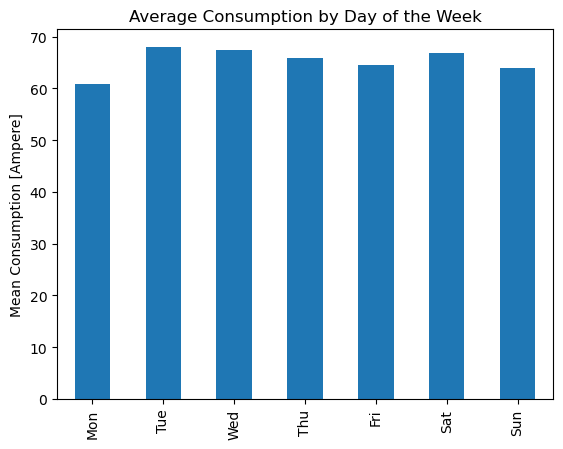

In [60]:
def day_week_plot(
    df: pd.DataFrame,
    day_week: str,
    target_col: str,
    title: Optional[str] = "Average Consumption by Day of the Week",
    ylabel: str = "Mean Consumption [Ampere]"
) -> None:
    
    """
    Plots the average target value by day of the week.
    """

    if target_col not in df.columns:
        raise ValueError(f"Column '{target_col}' not found in DataFrame.")
    if day_week not in df.columns:
        raise ValueError(f"Column '{day_week}' not found in DataFrame.")

    df = df.copy()
    df[day_week] = df.index.dayofweek
    dow = df.groupby(day_week)[target_col].mean()
    
    dow.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

    dow.plot(kind='bar')
    plt.title(title)
    plt.ylabel(ylabel)
    plt.show()

day_week_plot(df=df_features, day_week='day_week', target_col=TARGET_COL)

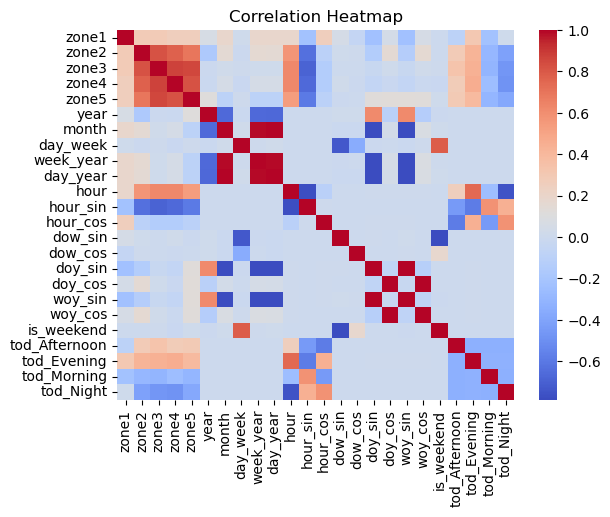

In [62]:
import seaborn as sns

def correlation_features(df:pd.DataFrame):
    sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
    plt.title('Correlation Heatmap')
    plt.show()

correlation_features(df_features)

In [69]:
def complete_analysis(df, resample_rule):
    df_resampled = load_and_prepare(CSV_PATH, dt_col=DATETIME_COL, resample_rule=resample_rule)

    print("--- df description ---")
    print(df_resampled.describe())

    df_no_outliers = interquartile_range(df=df_resampled, target_col=TARGET_COL)

    print("\n --- df after removing outliers ---")
    print(df_no_outliers)

    time_plot(df=df_no_outliers, target_col=TARGET_COL, title='Energy Consuption')

    df_features = extra_features(df_no_outliers)

    hour_plot(df_features, 'hour', TARGET_COL)

    day_week_plot(df_features, 'day_week', target_col=TARGET_COL)

    correlation_features(df_features)

    return df_features

## 1 hour

/home/bibi/Documentos/GitHub/energy-load-forecasting/lstm.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(csv_path, decimal=decimal, quotechar='"', parse_dates=[dt_col])


--- df description ---
              zone1         zone2         zone3         zone4         zone5
count  14816.000000  14816.000000  14816.000000  14816.000000  14816.000000
mean     393.152015    659.368006    908.601822    681.417122    721.234215
std      111.557829    200.564100    241.428761    155.419130    200.368129
min        0.000000      0.000000      0.000000      0.000000      0.000000
25%      304.932500    491.412500    696.820000    556.412500    558.905000
50%      386.240000    657.745000    936.290000    693.750000    717.535000
75%      466.442500    787.357500   1111.392500    797.230000    879.560000
max     1014.490000   2798.990000   1806.340000   1411.010000   1611.740000
Q1: 304.9325
Q3: 466.4425
IQR: 161.51
Lower Bound: 62.66750000000002
Upper Bound: 708.7075

 --- df after removing outliers ---
                      zone1   zone2    zone3   zone4   zone5
DateTime                                                    
2022-09-14 17:00:00  385.48  620.27   805.5

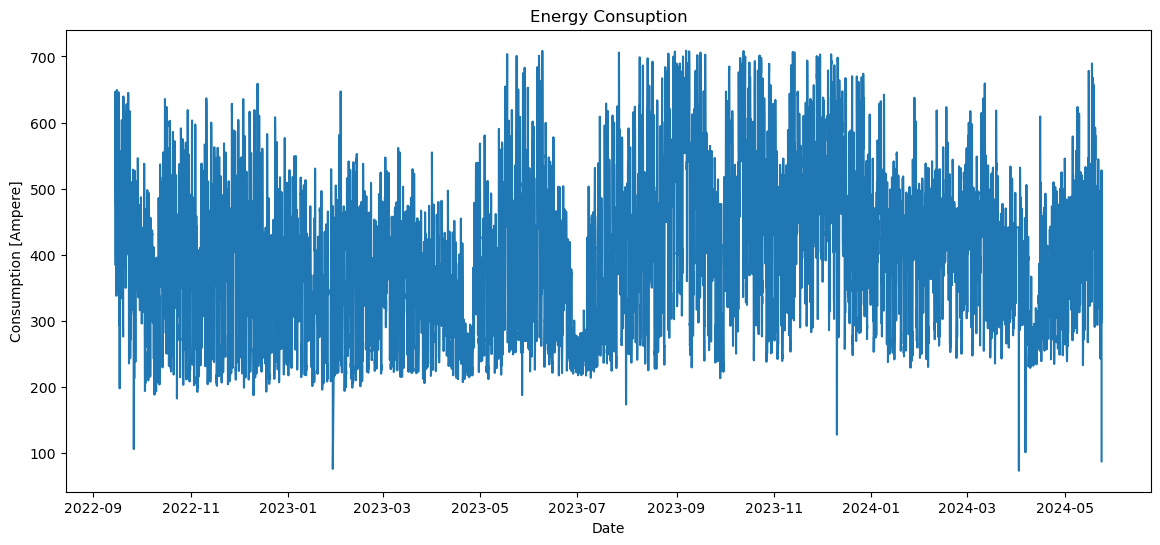

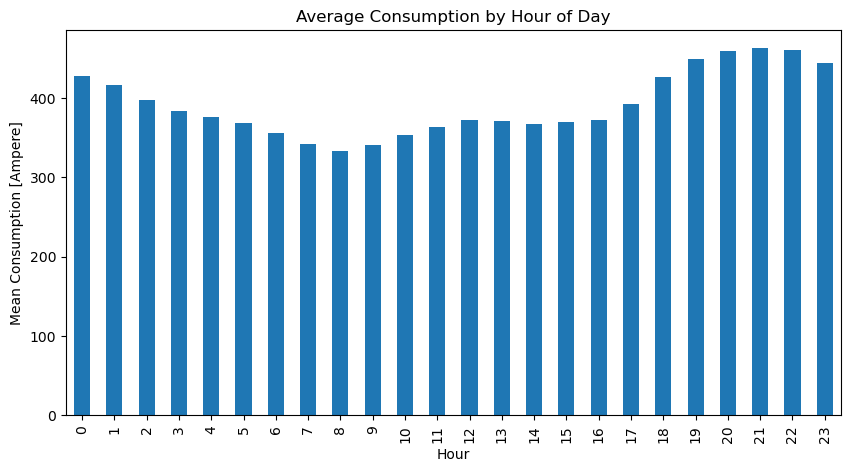

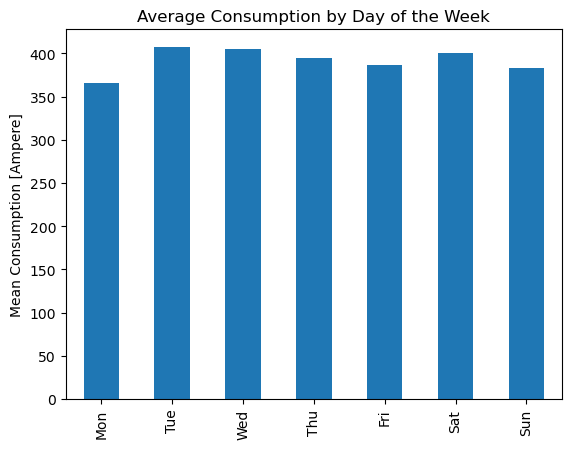

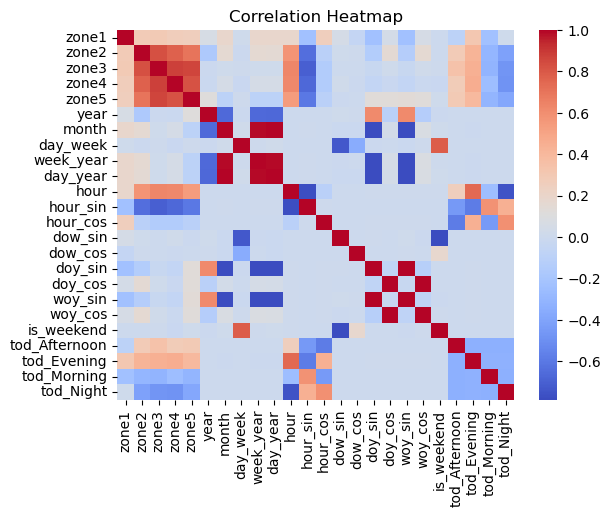

In [70]:
df_features_1h = complete_analysis(df_10min, 'h')

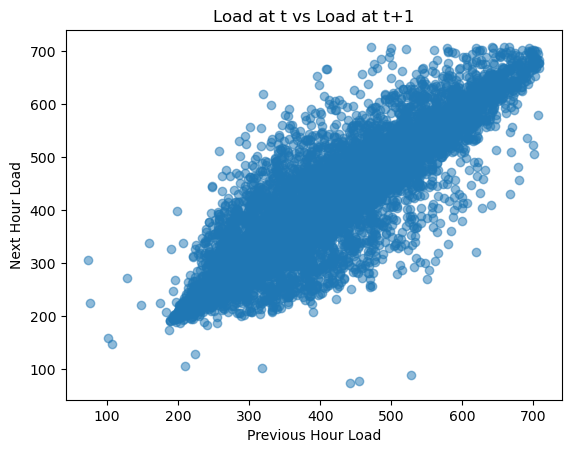

In [71]:
plt.scatter(df_features_1h[TARGET_COL][:-1], df_features_1h[TARGET_COL][1:], alpha=0.5)
plt.title('Load at t vs Load at t+1')
plt.xlabel('Previous Hour Load')
plt.ylabel('Next Hour Load')
plt.show()

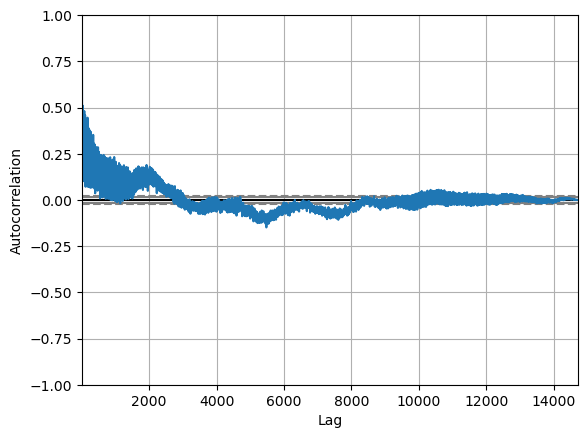

In [83]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(df_features_1h[TARGET_COL])
plt.show()

<Figure size 1000x500 with 0 Axes>

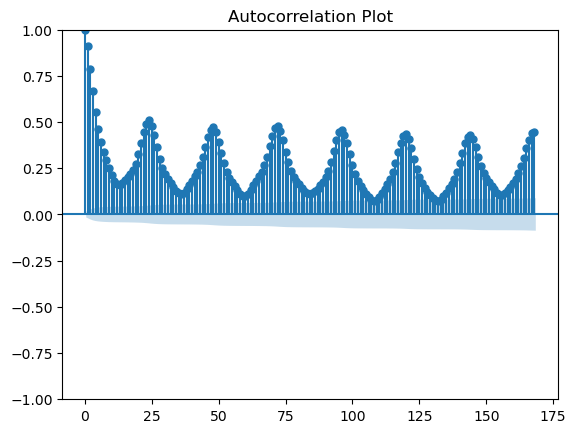

In [91]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plot_acf(df_features_1h[TARGET_COL], lags=24*7)  # 1 week
plt.title("Autocorrelation Plot")
plt.show()

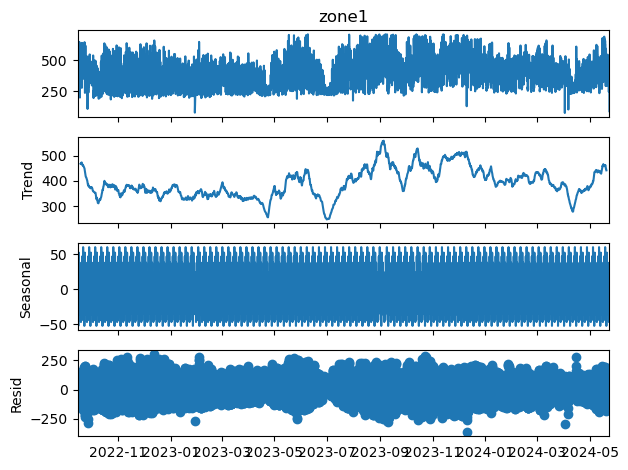

In [97]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df_features_1h[TARGET_COL], model='additive', period=24*7) # 1 week
decomp.plot()
plt.show()

## 1 day

/home/bibi/Documentos/GitHub/energy-load-forecasting/lstm.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(csv_path, decimal=decimal, quotechar='"', parse_dates=[dt_col])


--- df description ---
              zone1         zone2         zone3         zone4        zone5
count    619.000000    619.000000    619.000000    619.000000    619.00000
mean    9410.242746  15782.223554  21747.729564  16309.977512  17263.01475
std     1870.917522   2435.166255   2008.957051   1612.649847   2020.09084
min       87.810000    141.740000      0.000000      0.000000      0.00000
25%     8252.325000  14421.745000  21262.420000  15877.610000  16767.12500
50%     9223.490000  15588.780000  22049.050000  16178.460000  17485.49000
75%    10468.490000  16959.815000  22626.075000  16706.935000  18274.14000
max    15459.400000  24174.350000  26833.470000  22439.540000  26253.00000
Q1: 8252.325
Q3: 10468.49
IQR: 2216.164999999999
Lower Bound: 4928.077500000002
Upper Bound: 13792.7375

 --- df after removing outliers ---
               zone1     zone2     zone3     zone4     zone5
DateTime                                                    
2022-09-15  11673.44  16631.58  21839.7

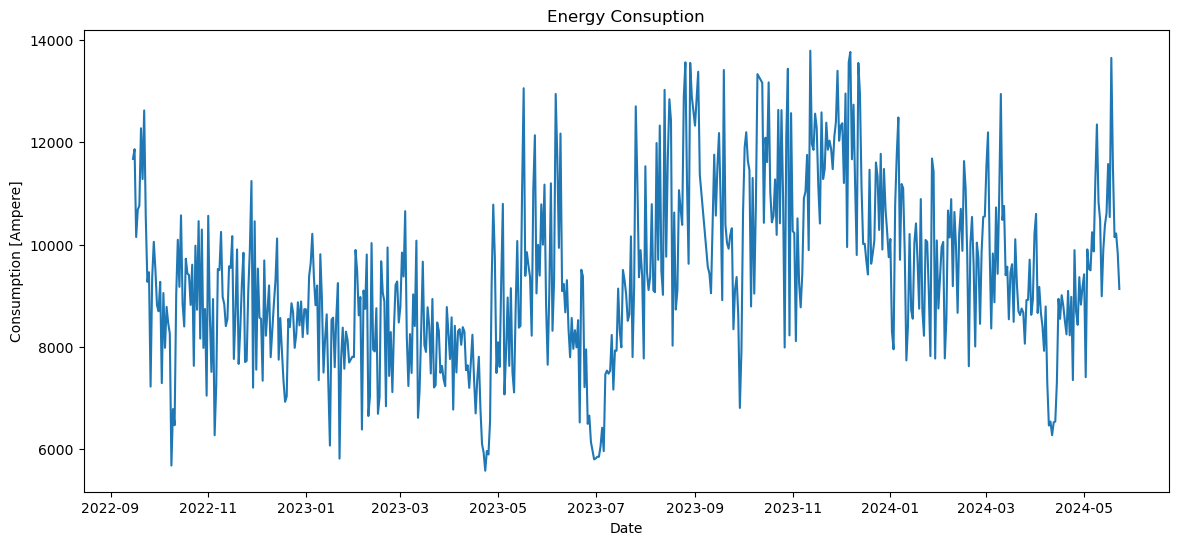

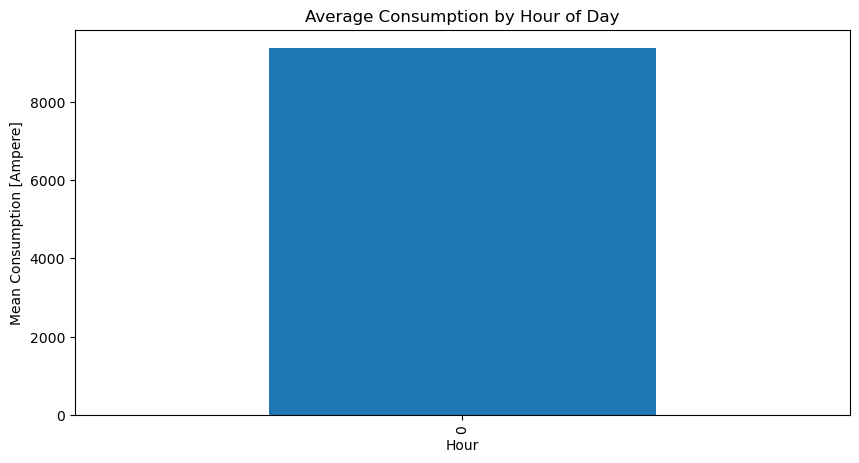

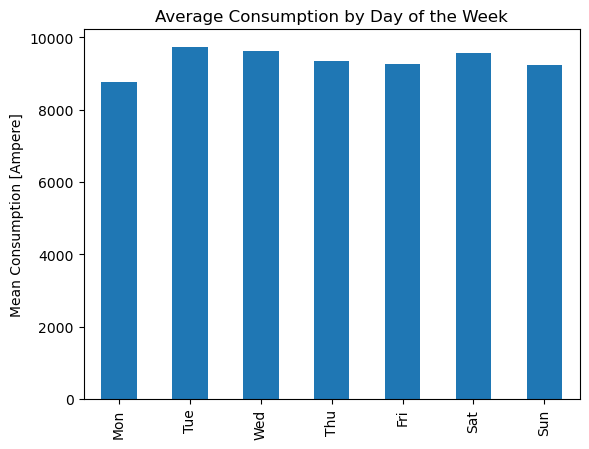

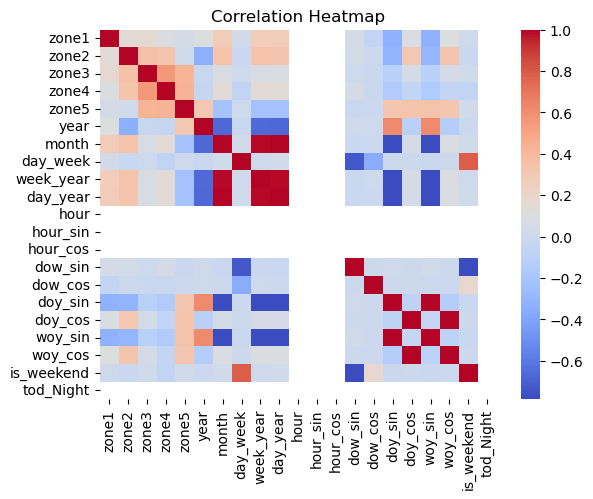

In [77]:
df_features_1d = complete_analysis(df_10min, 'd')

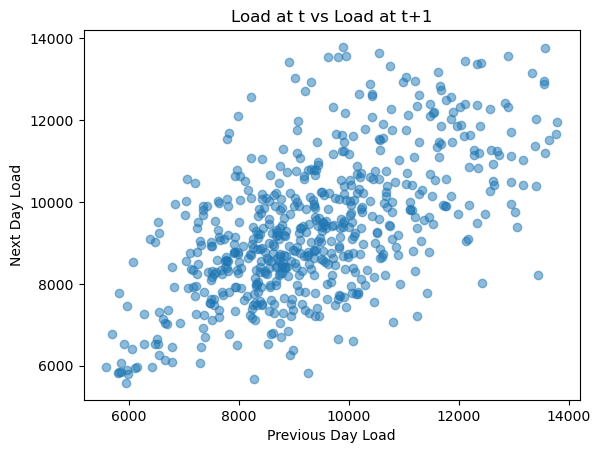

In [79]:
plt.scatter(df_features_1d[TARGET_COL][:-1], df_features_1d[TARGET_COL][1:], alpha=0.5)
plt.title('Load at t vs Load at t+1')
plt.xlabel('Previous Day Load')
plt.ylabel('Next Day Load')
plt.show()

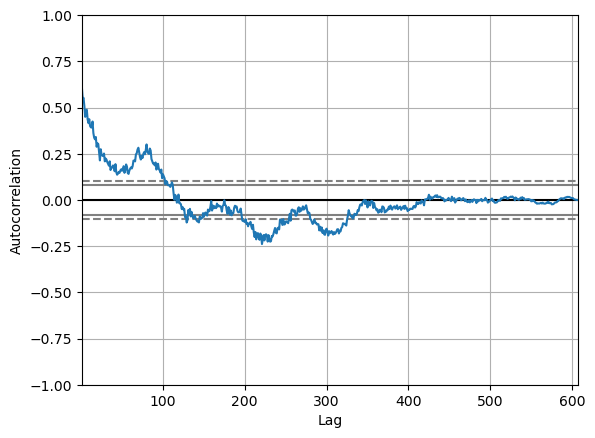

In [84]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(df_features_1d[TARGET_COL])
plt.show()

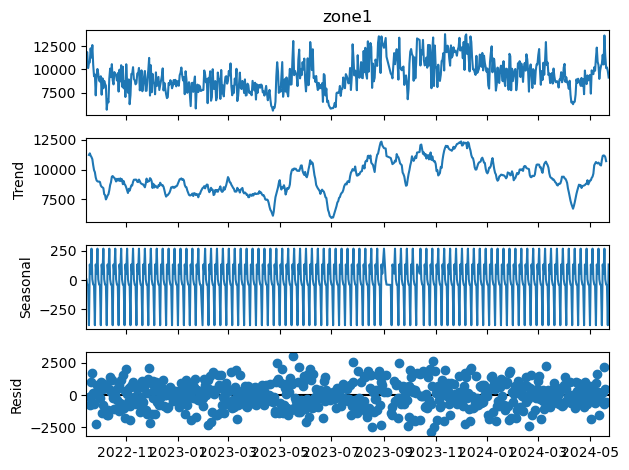

In [89]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df_features_1d[TARGET_COL], model='additive', period=7)
decomp.plot()
plt.show()